In [33]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text 
from sklearn.inspection import permutation_importance
import json 
from datetime import datetime
import joblib
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [34]:
df = pd.read_csv('./data/S06-hw-dataset-02.csv')
print("\nПервые строки датасета (head):\n", df.head())
print("\nИнформация о столбцах и типах (info):\n")
df.info()

print("Проверка столбцов на пропуски:\n")
df.isna().mean()

print("Типы данных столбцов:\n")
print(df.dtypes)

target_counts = df['target'].value_counts()
print(target_counts)
print("Доли классов:")
print(target_counts / len(df) * 100)




Первые строки датасета (head):
    id       f01       f02       f03        f04       f05       f06       f07  \
0   1 -0.149235 -2.826966 -0.522901  -4.198449  1.364943  0.815043 -1.195518   
1   2 -1.966180 -4.877542  0.268367  -9.607791  0.097149  1.347185 -3.872575   
2   3 -0.555964 -0.999920  0.209673 -14.119498 -1.808950 -0.006222 -4.651108   
3   4 -2.049199 -5.600713 -1.664677  -6.263893 -5.224455  0.848351  1.407210   
4   5 -0.220556  4.889479 -2.235840   6.450046  0.774389 -2.382625  2.584816   

        f08       f09  ...       f29       f30       f31       f32       f33  \
0 -1.932232  2.396353  ... -0.159323  0.448015  0.572745  0.149916  0.878392   
1 -0.395117  1.710068  ... -0.389212  1.383794  0.169876  0.043969 -0.963545   
2  0.911944 -0.289037  ... -1.383970  3.044321 -0.182864  1.425649 -8.418598   
3 -0.542080  0.119102  ... -2.713080  2.762637 -0.520796 -0.142455  1.668338   
4  4.211856 -0.317889  ... -1.302872  2.478862  1.528610  1.098131  3.547087   

     

In [35]:
#Выделяем Х признаки и y таргет
X = df[[x for x in df.columns if not 'id' in x and not 'target' in x]]
y = df['target']
print(X, y)
print(f"Количество признаков: {X.shape[1]}")
print(f"Имена признаков: {list(X.columns)}")

            f01       f02       f03        f04       f05       f06       f07  \
0     -0.149235 -2.826966 -0.522901  -4.198449  1.364943  0.815043 -1.195518   
1     -1.966180 -4.877542  0.268367  -9.607791  0.097149  1.347185 -3.872575   
2     -0.555964 -0.999920  0.209673 -14.119498 -1.808950 -0.006222 -4.651108   
3     -2.049199 -5.600713 -1.664677  -6.263893 -5.224455  0.848351  1.407210   
4     -0.220556  4.889479 -2.235840   6.450046  0.774389 -2.382625  2.584816   
...         ...       ...       ...        ...       ...       ...       ...   
17995 -1.920557 -1.422719 -1.031828   2.094948 -0.067437 -0.469716  1.427896   
17996 -1.914101 -2.124938  1.216011  -9.308270 -1.024236 -0.301606 -5.320400   
17997 -1.846604  7.583639 -1.107318   3.319625  3.065063  0.791241 -2.855133   
17998  1.742157  1.722399 -0.849028   5.751745  3.271935 -1.666774  4.501935   
17999 -2.157094  1.365535  0.365606   1.942476  2.977828 -0.398900 -0.582218   

            f08       f09       f10  ..

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")

Размер train: (13500, 37)
Размер test: (4500, 37)


## Краткое пояснение почему важны `random_state` и `stratify`

- `random_state`: Важно для того, чтобы результат был воспроизводимым 

- `stratify`: сохраняет доли классов в обоих выборках

In [37]:
# делаю два baseline'а

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Dummy stratified
dummy_strat = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

dummy_strat.fit(X_train, y_train)



y_pred_dm = dummy_strat.predict(X_test)
y_proba_dm = dummy_strat.predict_proba(X_test)[:, 1]

# Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

def calculate_metrics(y_test, y_pred, y_proba):
    return {
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred,  zero_division=0)),
        'F1 score': float(f1_score(y_test, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba)) if y_proba is not None else None
    }

metrics_dummy = calculate_metrics(y_test, y_pred_dm, y_proba_dm)
metrics_lr = calculate_metrics(y_test, y_pred_lr, y_proba_lr)

metrics_all = {
    "Dummy Stratified": metrics_dummy,
    "Logistic Regression": metrics_lr,
}


with open('./artifacts/metrics_dummy.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_dummy, f, indent=2, ensure_ascii=False)
    
with open('./artifacts/metrics_logistic_regression.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_lr, f, indent=2, ensure_ascii=False)

Метрики для бейзлайнов, `accuracy` для DummyClassifier составила 0.618, когда для LogisticRegression она же составила 0.816, все метрики в целом оказались больше у LogisticRegression

## Дерево решений 

Лучший alpha по test accuracy: 0.0


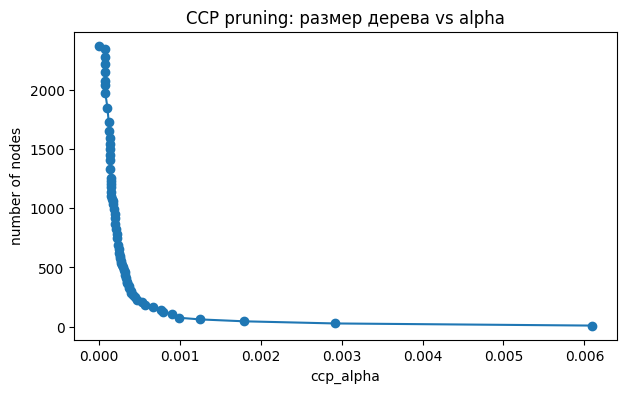

Decision Tree - best: 
{'accuracy': 0.802, 'precision': 0.6238297872340426, 'recall': 0.6201353637901861, 'F1 score': 0.621977089520577, 'roc_auc': 0.7434612925038935}


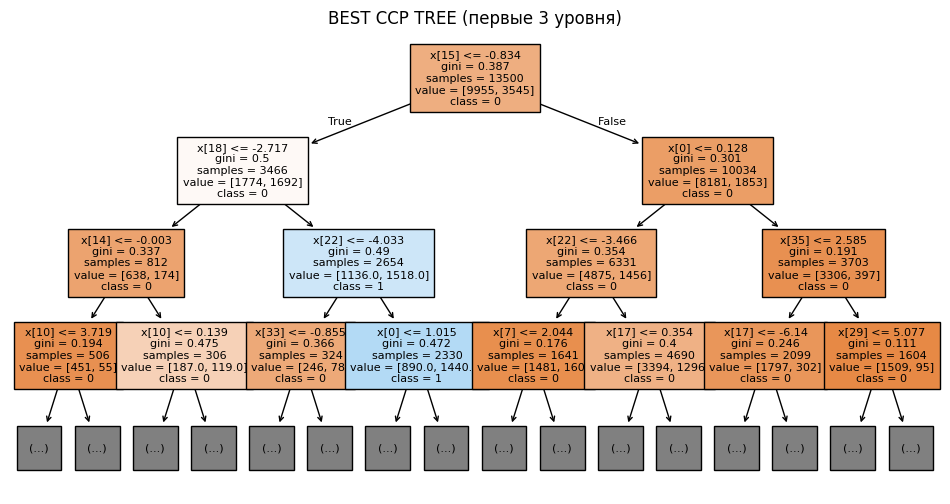

In [50]:
# DecesionTree 
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

ccp_alphas = np.unique(ccp_alphas)
if len(ccp_alphas) > 60:
    ccp_alphas = ccp_alphas[:: max(1, len(ccp_alphas)//60)]
    
train_scores = []
node_counts = []

models = []

for a in ccp_alphas:
    model = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=float(a))
    model.fit(X_train, y_train)
    models.append(model)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    node_counts.append(model.tree_.node_count)
    
best_idx = int(np.argmax(train_scores))
best_alpha = float(ccp_alphas[best_idx])
best_model = models[best_idx]



print(f"Лучший alpha по test accuracy: {best_alpha}")
# Показываю как меняется размер дерева со сложностью альфы 
plt.figure(figsize=(7, 4))
plt.plot(ccp_alphas, node_counts, marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("number of nodes")
plt.title("CCP pruning: размер дерева vs alpha")
plt.show()

    
metrics_ccp_tree = calculate_metrics(y_test, best_model.predict(X_test), best_model.predict_proba(X_test)[:, 1])

best_params_tree = {"Best Params": best_alpha, "best_metrics": dict(metrics_ccp_tree)}

metrics_all["Decision Tree"] = metrics_ccp_tree
print(f"Decision Tree - best: \n{metrics_ccp_tree}")


search_summaries = {}
search_summaries["Decision Tree"] = best_params_tree


with open('./artifacts/metrics_ccp_tree.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_ccp_tree, f, indent=2, ensure_ascii=False)
    
plt.figure(figsize=(12, 6))
plot_tree(best_model, max_depth=3, 
          filled=True, 
          class_names=["0", "1"], 
          fontsize=8, 
          )
plt.title("BEST CCP TREE (первые 3 уровня)")
plt.savefig("./artifacts/figures/best_ccp_tree.png", dpi=150, bbox_inches="tight")
plt.show()

## Ансамбль типа беггинг (bootstrap), случайный лес 

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(
    n_estimators=400, 
    random_state=RANDOM_STATE, 
    oob_score=True, 
    n_jobs=1, 
    max_features=10, 
)

rf.fit(X_train, y_train)

print(f"Random Forest, oob score = {rf.oob_score_:.4f}")
random_forest_metrics = calculate_metrics(y_test, y_pred=rf.predict(X_test), y_proba=rf.predict_proba(X_test)[:,1])
print(random_forest_metrics)
metrics_all["Random Forest"] = random_forest_metrics 
with open('./artifacts/random_forest_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(random_forest_metrics, f, indent=2, ensure_ascii=False)



Random Forest, oob score = 0.8950
{'accuracy': 0.8968888888888888, 'precision': 0.9174418604651163, 'recall': 0.6675126903553299, 'F1 score': 0.7727717923604309, 'roc_auc': 0.9284014843916534}


## AdaBoost

In [40]:
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

ada = AdaBoostClassifier(
    estimator=stump, 
    n_estimators=500,
    learning_rate=0.6,
    random_state=RANDOM_STATE
)

ada.fit(X_train, y_train)
ada_metrics = calculate_metrics(y_test, ada.predict(X_test), ada.predict_proba(X_test)[:, 1])

metrics_all["AdaBoost"] = ada_metrics
print(ada_metrics)

{'accuracy': 0.8277777777777777, 'precision': 0.8023774145616642, 'recall': 0.45685279187817257, 'F1 score': 0.5822102425876011, 'roc_auc': 0.8341312932892321}


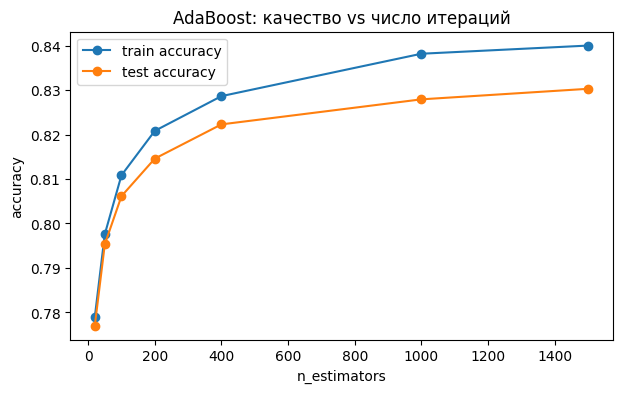

In [51]:
n_estimators_grid = [20, 50, 100, 200, 400, 1000, 1500]
train_acc = []
test_acc = []

param_grid = {
    'n_estimators': [20, 50, 100, 200, 400, 1000, 1500],
    'learning_rate': [0.6]
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=stump,
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    cv=5,  
    scoring='accuracy',
    n_jobs=-1,  
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

results = grid_search.cv_results_

train_acc = results['mean_train_score']
test_acc = results['mean_test_score']
n_estimators_grid = param_grid['n_estimators']

best_params_ada = {"Best Params": grid_search.best_params_ ,"Best Score(CV)": grid_search.best_score_}

search_summaries["AdaBoost"] = best_params_ada

with open('./artifacts/search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=2, ensure_ascii=False)

plt.figure(figsize=(7, 4))
plt.plot(n_estimators_grid, train_acc, marker="o", label="train accuracy")
plt.plot(n_estimators_grid, test_acc, marker="o", label="test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("accuracy")
plt.title("AdaBoost: качество vs число итераций")
plt.legend()
plt.show()

## Стекинг 

In [42]:

# создаем массив из 3 базовых моделей 
estimators = [
    ('lr', Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=2000))])),
    ('rf', RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE)),
]


final_est = LogisticRegression(max_iter=2000)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=final_est,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack.fit(X_train, y_train)

stack_metrics = calculate_metrics(y_test, stack.predict(X_test), stack.predict_proba(X_test)[:, 1])
metrics_all["Stacking"] = stack_metrics
print(stack_metrics)

{'accuracy': 0.9135555555555556, 'precision': 0.8838334946757018, 'recall': 0.772419627749577, 'F1 score': 0.8243792325056434, 'roc_auc': 0.9325450371199904}


                     accuracy  precision    recall  F1 score   roc_auc
Dummy Stratified     0.618000   0.267532  0.261421  0.264442  0.503224
Logistic Regression  0.816222   0.736983  0.467005  0.571724  0.800890
Decision Tree        0.802000   0.623830  0.620135  0.621977  0.743461
Random Forest        0.896889   0.917442  0.667513  0.772772  0.928401
AdaBoost             0.827778   0.802377  0.456853  0.582210  0.834131
Stacking             0.913556   0.883833  0.772420  0.824379  0.932545


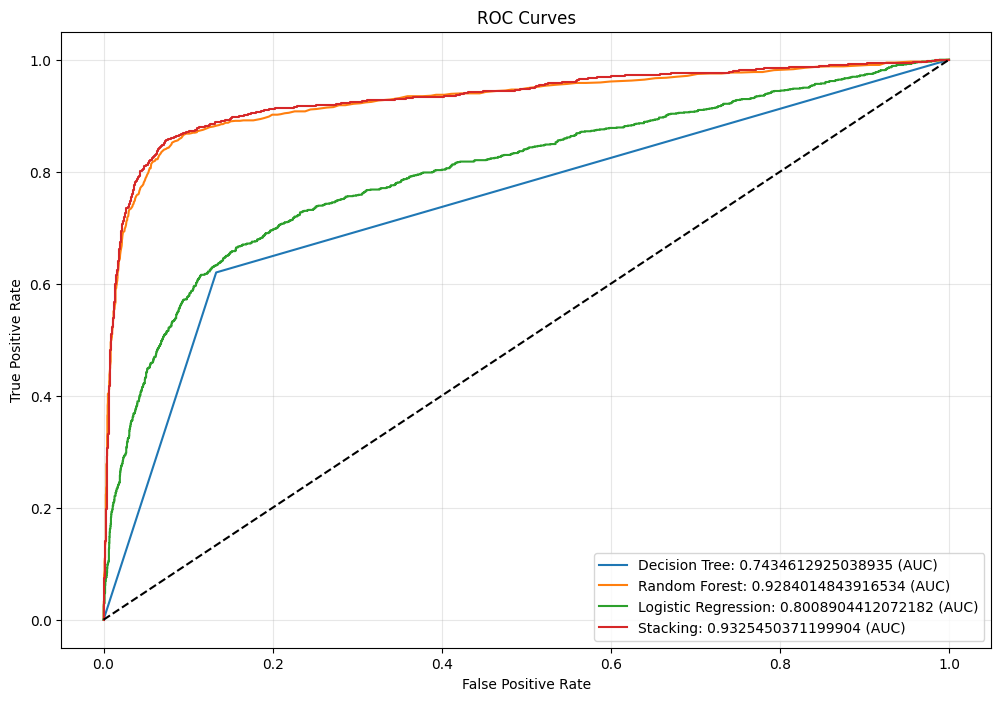

Лучшая модель по roc_auc: Stacking


In [43]:
metrics_df = pd.DataFrame(metrics_all).T
print(metrics_df)

models = {
    "Decision Tree": best_model, 
    "Random Forest": rf,
    "Logistic Regression": pipe_lr,
    "Stacking": stack
}

plt.figure(figsize=(12,8))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name}: {auc_score} (AUC)")
        

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('./artifacts/figures/ROC-curve.png', dpi=300, bbox_inches='tight')
plt.show()


best_model_name = metrics_df['roc_auc'].idxmax()
print(f'Лучшая модель по roc_auc: {best_model_name}')


Permutation Importance для Stacking:

15 важных признаков:
   feature  importance_mean  importance_std
15     f16           0.0424        0.005886
0      f01           0.0212        0.002135
11     f12           0.0176        0.003200
6      f07           0.0132        0.005115
22     f23           0.0128        0.002482
12     f13           0.0112        0.002786
17     f18           0.0112        0.001166
4      f05           0.0110        0.002608
28     f29           0.0104        0.001356
7      f08           0.0096        0.001020
29     f30           0.0082        0.003655
3      f04           0.0080        0.003795
32     f33           0.0076        0.001497
1      f02           0.0074        0.002728
18     f19           0.0074        0.003137


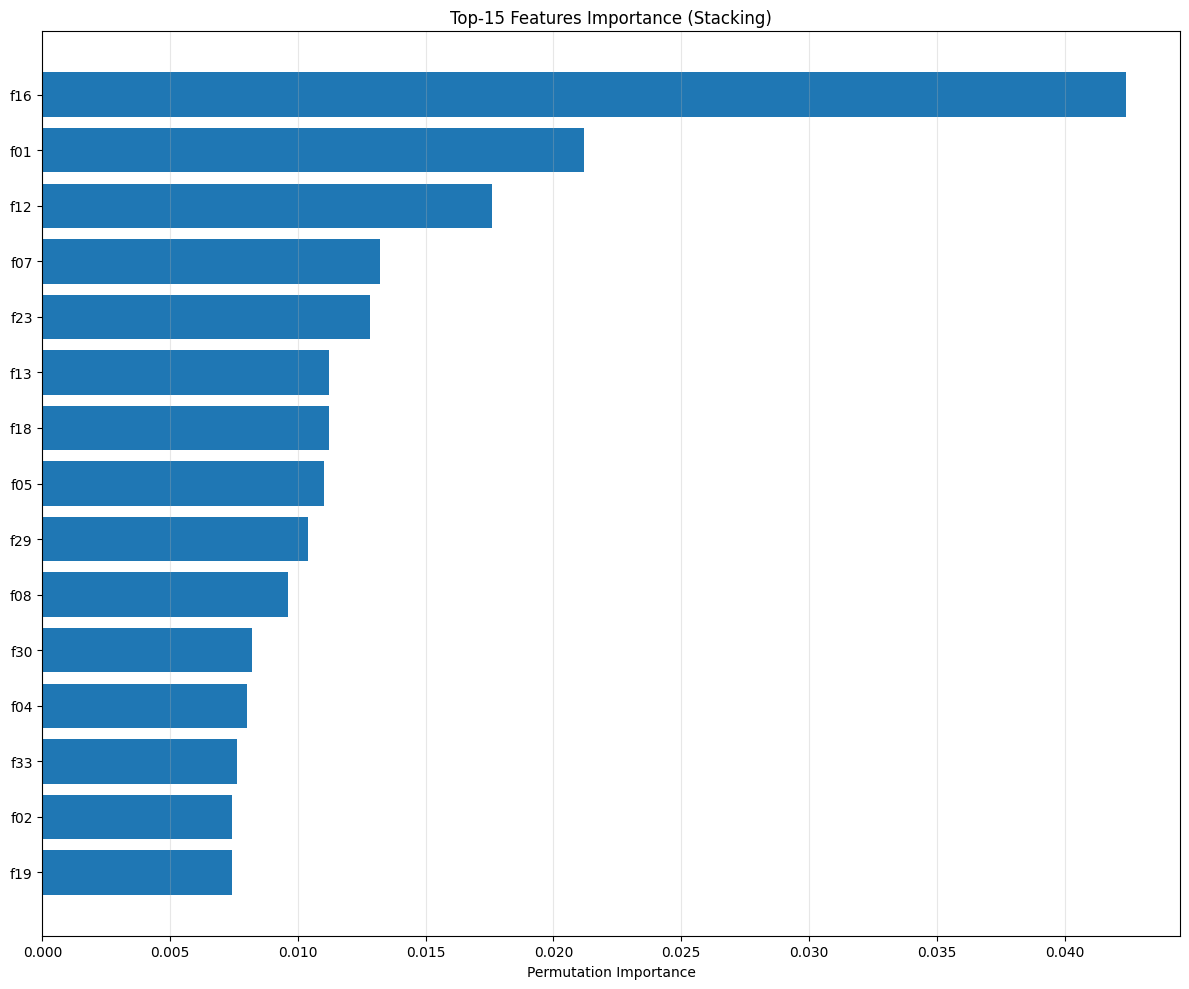

In [44]:

print(f"\nPermutation Importance для {best_model_name}:")
if len(X_test) > 1000:
    sample_idx = np.random.choice(len(X_test), 1000, replace=False)
    X_test_sample = X_test.iloc[sample_idx]
    y_test_sample = y_test.iloc[sample_idx]
else:
    X_test_sample, y_test_sample = X_test, y_test

res = permutation_importance(
    stack, X_test_sample, y_test_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': res.importances_mean,
    'importance_std': res.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n15 важных признаков:")
print(importance_df.head(15))

plt.figure(figsize=(12, 10))
top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n)
plt.barh(range(top_n), top_features['importance_mean'][::-1])
plt.yticks(range(top_n), top_features['feature'][::-1])
plt.xlabel('Permutation Importance')
plt.title(f'Top-{top_n} Features Importance ({best_model_name})')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("artifacts/figures/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

In [45]:
stack_meta = {
    "model_name": best_model_name, 
    "test_metrics": stack_metrics,
    "top_features": importance_df.head(15).to_dict('records'),
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_state": RANDOM_STATE,
    "test_size": 0.25,
    "dataset": "S06-hw-dataset-02.csv"
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(stack_meta, f, indent=2)

In [46]:
try: 
    joblib.dump(rf, './artifacts/figures/best_model.joblib')
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")

In [47]:
print(metrics_df)

                     accuracy  precision    recall  F1 score   roc_auc
Dummy Stratified     0.618000   0.267532  0.261421  0.264442  0.503224
Logistic Regression  0.816222   0.736983  0.467005  0.571724  0.800890
Decision Tree        0.802000   0.623830  0.620135  0.621977  0.743461
Random Forest        0.896889   0.917442  0.667513  0.772772  0.928401
AdaBoost             0.827778   0.802377  0.456853  0.582210  0.834131
Stacking             0.913556   0.883833  0.772420  0.824379  0.932545


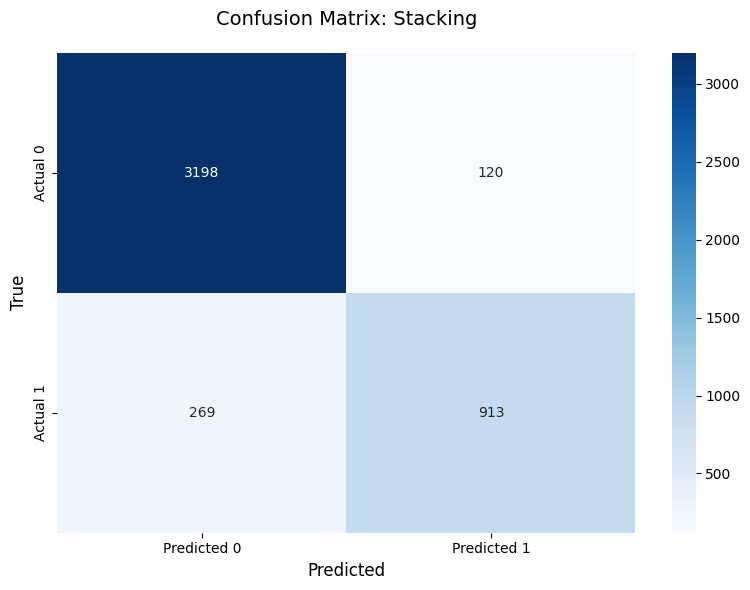

In [48]:
def plot_confusion_matrix_heatmap(y_true, y_pred, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=20)
    plt.ylabel('True', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    
    plt.savefig('./artifacts/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    return cm

stack_cm = plot_confusion_matrix_heatmap(y_test, y_pred=stack.predict(X_test), model_name="Stacking")

In [49]:
with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics_all, f, indent=2)